#### Importing necessary libraries:
• Pandas to process data\
• Matplotlib and seaborn for plots

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Importing data
Dataset file has been imported from drive, then stored as a Pandas data frame.

In [2]:
#need to extract the file ID from the Google Sheets link first. I will modify the cell to correctly use the file ID with gdown
piano_tr_ds = "1MU5ySth0sT-dM1ng6XSOjHqRHsIK0GEmzzpolT_IlWY"
file_id = 'piano_training_ds.xlsx'
!pip install gdown
!gdown --id {piano_tr_ds} -O {file_id}
try:
    df_drive = pd.read_excel(file_id)
except FileNotFoundError:
    print(f"Error: {file_id} not found after download. Check your file ID and permissions.")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1MU5ySth0sT-dM1ng6XSOjHqRHsIK0GEmzzpolT_IlWY
From (redirected): https://docs.google.com/spreadsheets/d/1MU5ySth0sT-dM1ng6XSOjHqRHsIK0GEmzzpolT_IlWY/export?format=xlsx
To: /content/piano_training_ds.xlsx
164kB [00:00, 18.3MB/s]


#### Number of protein complexes in the dataset
To derive the amount of complexes in the dataset and the number of occurrences of each complex, the Pandas method <.value_counts()> was used on the column reporting the PDB IDs and stored in a dictionary using the method <to_dict()>.

In [3]:
pdb_occurrences = df_drive['PDB'].value_counts().to_dict()
print(pdb_occurrences)
print(len(pdb_occurrences))

{'3BT1': 240, '3SGB': 191, '1CHO': 191, '1R0R': 191, '1PPF': 190, '1A22': 140, '1DAN': 89, '1AO7': 86, '3S9D': 81, '3HFM': 73, '1MHP': 68, '3BN9': 60, '1JTG': 58, '1GC1': 54, '3NPS': 54, '1C4Z': 48, '1EMV': 46, '1VFB': 45, '1BP3': 45, '2JEL': 43, '1JRH': 43, '3NGB': 41, '2NYY': 40, '1OGA': 40, '1LFD': 38, '1JTD': 36, '1IAR': 36, '4RS1': 36, '4P23': 35, '4P5T': 35, '3C60': 35, '4NKQ': 34, '3BE1': 34, '3BDY': 34, '1A4Y': 32, '1CBW': 31, '1BRS': 30, '2NZ9': 29, '1BJ1': 29, '4G0N': 29, '3SE8': 28, '2G2U': 27, '1EAW': 27, '1KTZ': 27, '2BNR': 26, '2WPT': 26, '1DVF': 26, '1MI5': 25, '3QHY': 25, '3SE9': 25, '3SE4': 25, '3QIB': 22, '3SZK': 21, '1DQJ': 21, '1B41': 20, '1FSS': 20, '2AK4': 20, '1CZ8': 19, '1FFW': 19, '1K8R': 19, '2FTL': 19, '5C6T': 18, '1XD3': 18, '1FC2': 18, '4PWX': 18, '3M62': 18, '1TM1': 17, '1Z7X': 17, '3SE3': 17, '1AK4': 16, '2J0T': 16, 100000000000000007629769841091887003294964970946560: 16, '1YY9': 16, '5M2O': 14, '2VLJ': 14, '3QDJ': 14, '3QDG': 14, '3BK3': 13, '1KNE': 13, 

To verify the amount of mutations is the one reported in the paper:

In [5]:
total_occurrences = sum(pdb_occurrences.values())
print(f"The total sum of all PDB occurrences is: {total_occurrences}\nThis is the amount of single-point mutations.")

The total sum of all PDB occurrences is: 4310
This is the amount of single-point mutations.


#### Occurrences per PDB ID distribution plotted

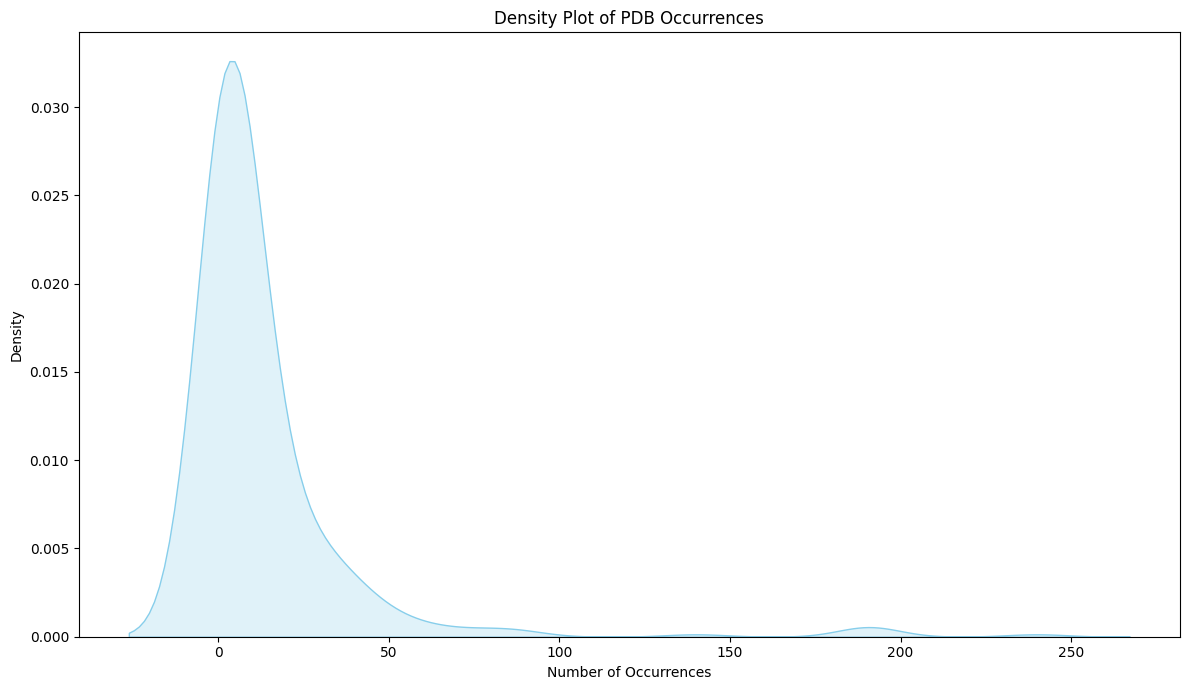

In [6]:
pdb_counts_series = pd.Series(pdb_occurrences)

plt.figure(figsize=(12, 7))
sns.kdeplot(pdb_counts_series.values, fill=True, color='skyblue')
plt.title('Density Plot of PDB Occurrences')
plt.xlabel('Number of Occurrences')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

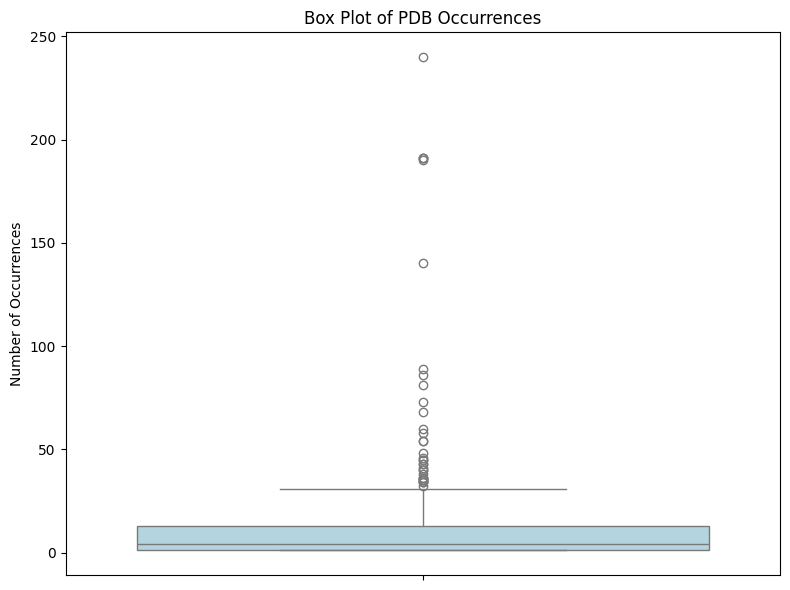

In [7]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=pdb_counts_series.values, color='lightblue')
plt.title('Box Plot of PDB Occurrences')
plt.ylabel('Number of Occurrences')
plt.tight_layout()
plt.show()

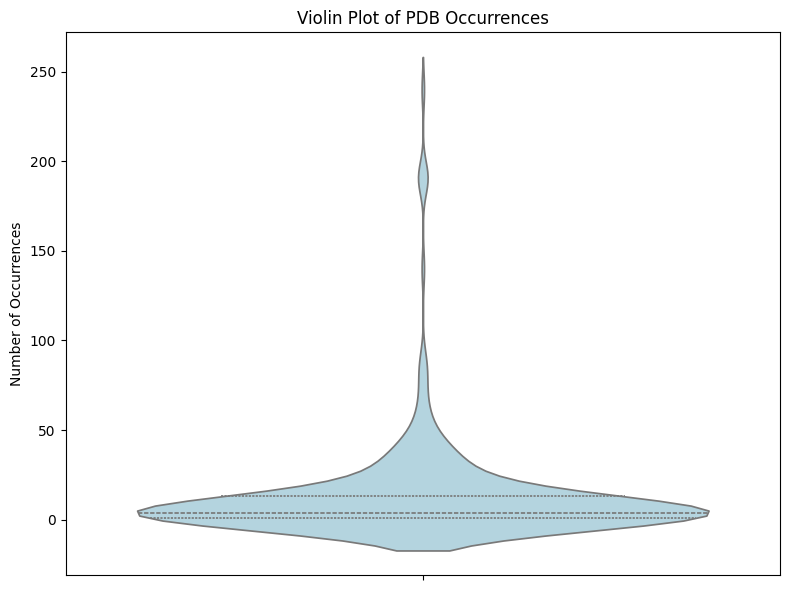

In [8]:
plt.figure(figsize=(8, 6))
sns.violinplot(y=pdb_counts_series.values, inner='quartile', color='lightblue')
plt.title('Violin Plot of PDB Occurrences')
plt.ylabel('Number of Occurrences')
plt.tight_layout()
plt.show()

#### Easy visualization of dataset

In [10]:
df_drive

,Dataset,PDB,Uniprots,Partners,Chain,Residue index,Wild-type,Mutant,ΔΔG (kcal/mol)
0,Training,3K2M,P00519,A_D,D,87,Y,A,4.000
1,Training,3K2M,P00519,A_D,D,36,Y,A,3.700
2,Training,3K2M,P00519,A_D,D,80,W,A,4.000
3,Training,3K2M,P00519,A_D,D,35,Y,A,1.000
4,Training,3K2M,P00519,A_D,D,88,M,A,4.000
...,...,...,...,...,...,...,...,...,...
4305,Benchmark test,1A4Y,"P03950,P13489",A_B,B,108,E,A,-0.323
4306,Benchmark test,1A4Y,"P03950,P13489",A_B,A,435,D,A,3.480
4307,Benchmark test,1A4Y,"P03950,P13489",A_B,A,437,Y,A,0.836
4308,Benchmark test,1A4Y,"P03950,P13489",A_B,A,457,R,A,-0.224


#### MISTAKE IN DATASET
The UniProt file for one of the proteins of the complex with the wrong PDB ID can be found at this link: https://www.uniprot.org/uniprotkb/P19878/entry#structure \
The wrong entries are from row 3884 to row 3905. Necessary to check all of them and find relative PDB IDs.\
#### Section of dataset with wrong PDB IDs.

In [11]:
df_drive[3884:3906]

,Dataset,PDB,Uniprots,Partners,Chain,Residue index,Wild-type,Mutant,ΔΔG (kcal/mol)
3884,Benchmark test,1000000000000000049861653971908893017010268485...,"P19878,P63000",A_B,A,38,D,N,2.160
3885,Benchmark test,1000000000000000049861653971908893017010268485...,"P19878,P63000",A_B,A,26,N,H,1.090
3886,Benchmark test,1000000000000000049861653971908893017010268485...,"P19878,P63000",A_B,A,132,K,E,-0.187
3887,Benchmark test,1000000000000000049861653971908893017010268485...,"P19878,P63000",A_B,A,134,L,R,-0.125
3888,Benchmark test,1000000000000000049861653971908893017010268485...,"P19878,P63000",A_B,A,33,I,N,2.010
3889,Benchmark test,1000000000000000049861653971908893017010268485...,"P19878,P63000",A_B,A,45,M,T,0.360
3890,Benchmark test,1000000000000000076297698410918870032949649709...,"Q01196,Q13951",A_B,B,65,S,A,0.120
3891,Benchmark test,1000000000000000076297698410918870032949649709...,"Q01196,Q13951",A_B,B,63,N,A,1.020
3892,Benchmark test,1000000000000000076297698410918870032949649709...,"Q01196,Q13951",A_B,A,149,T,A,1.040
3893,Benchmark test,1000000000000000076297698410918870032949649709...,"Q01196,Q13951",A_B,A,144,K,M,0.320


#### Dictionary where **key**: *PDB ID*; **value**: list of *Uniprot IDs*
Each list contains a single string of comma separated Uniprot IDs.

In [14]:
pdb_to_uniprots = df_drive.groupby('PDB')['Uniprots'].apply(lambda x: x.unique().tolist()).to_dict()
print(pdb_to_uniprots)

{100000000000000007629769841091887003294964970946560: ['Q01196,Q13951'], 1000000000000000049861653971908893017010268485438462151574892930611988399099305815384459015356416: ['P19878,P63000'], '1A22': ['P01241,P10912'], '1A4Y': ['P03950,P13489'], '1ACB': ['P01051,P00766'], '1AHW': ['P01837,P01868,X5J519,P13726'], '1AK4': ['P12497,P62937'], '1AO7': ['P14079,A0A075B6T6,A0A0K0K1A5,A0A5B9,P01848,P01850,P04439,P61769'], '1B2S': ['P00648,P11540'], '1B2U': ['P00648,P11540'], '1B3S': ['P00648,P11540'], '1B41': ['P0C1Z0,P22303'], '1BD2': ['P14079,P0C213,A0A0K0K1A5,A0A5B9,P01848,P04437,P04439,P61769'], '1BJ1': ['P15692'], '1BP3': ['P01241,P16471'], '1BRS': ['P00648,P11540'], '1C1Y': ['P04049,P62834'], '1C4Z': ['P68036,Q05086'], '1CBW': ['P00766,P00767,P00974'], '1CHO': ['P68390,P00766'], '1CSE': ['P00780,B0FXJ2,P01051'], '1CSO': ['P00777,P68390'], '1CT0': ['P00777,P68390'], '1CT2': ['P00777,P68390'], '1CT4': ['P00777,P68390'], '1CZ8': ['P15692'], '1DAN': ['P08709,P13726'], '1DQJ': ['P01837,P01865,

We need to count amount of proteins per PDB ID, so:\
• count occurrences using split with "," as separator\
• store the count in a dictionary

In [19]:
uniprot_counts_per_pdb = {}
for pdb, uniprot_list in pdb_to_uniprots.items():
    # The uniprot_list contains a single string, which might be comma-separated
    if uniprot_list:
        # Get the first (and only) string in the list
        uniprots_str = uniprot_list[0]
        # Split the string by comma and count the individual IDs
        count = len(uniprots_str.split(','))
        uniprot_counts_per_pdb[pdb] = count
    else:
        uniprot_counts_per_pdb[pdb] = 0 # Handle cases where the list is empty

print(uniprot_counts_per_pdb)

{100000000000000007629769841091887003294964970946560: 2, 1000000000000000049861653971908893017010268485438462151574892930611988399099305815384459015356416: 2, '1A22': 2, '1A4Y': 2, '1ACB': 2, '1AHW': 4, '1AK4': 2, '1AO7': 8, '1B2S': 2, '1B2U': 2, '1B3S': 2, '1B41': 2, '1BD2': 8, '1BJ1': 1, '1BP3': 2, '1BRS': 2, '1C1Y': 2, '1C4Z': 2, '1CBW': 3, '1CHO': 2, '1CSE': 3, '1CSO': 2, '1CT0': 2, '1CT2': 2, '1CT4': 2, '1CZ8': 1, '1DAN': 2, '1DQJ': 3, '1DVF': 4, '1EAW': 2, '1EFN': 2, '1EMV': 2, '1F47': 2, '1F5R': 2, '1FC2': 2, '1FCC': 2, '1FFW': 2, '1FR2': 2, '1FSS': 2, '1FY8': 2, '1GC1': 2, '1GCQ': 2, '1GL0': 2, '1GL1': 2, '1GRN': 2, '1GUA': 2, '1H9D': 2, '1HE8': 2, '1IAR': 2, '1JCK': 1, '1JRH': 3, '1JTD': 2, '1JTG': 2, '1K8R': 2, '1KAC': 2, '1KBH': 2, '1KIP': 2, '1KIQ': 2, '1KIR': 2, '1KNE': 2, '1KTZ': 2, '1LFD': 2, '1LP9': 5, '1M9E': 2, '1MAH': 2, '1MHP': 1, '1MI5': 5, '1MLC': 3, '1N8O': 2, '1N8Z': 1, '1NCA': 2, '1NMB': 1, '1OGA': 6, '1P69': 2, '1P6A': 2, '1PPF': 2, '1QSE': 2, '1R0R': 2, '1REW

Count total of the proteins in the dataset:

In [16]:
total_monomers = sum(uniprot_counts_per_pdb.values())
print(f"The total sum of all Uniprot occurrences is: {total_monomers}")

The total sum of all Uniprot occurrences is: 718


#### Plot the distribution of Uniprot occurrences per PDB ID

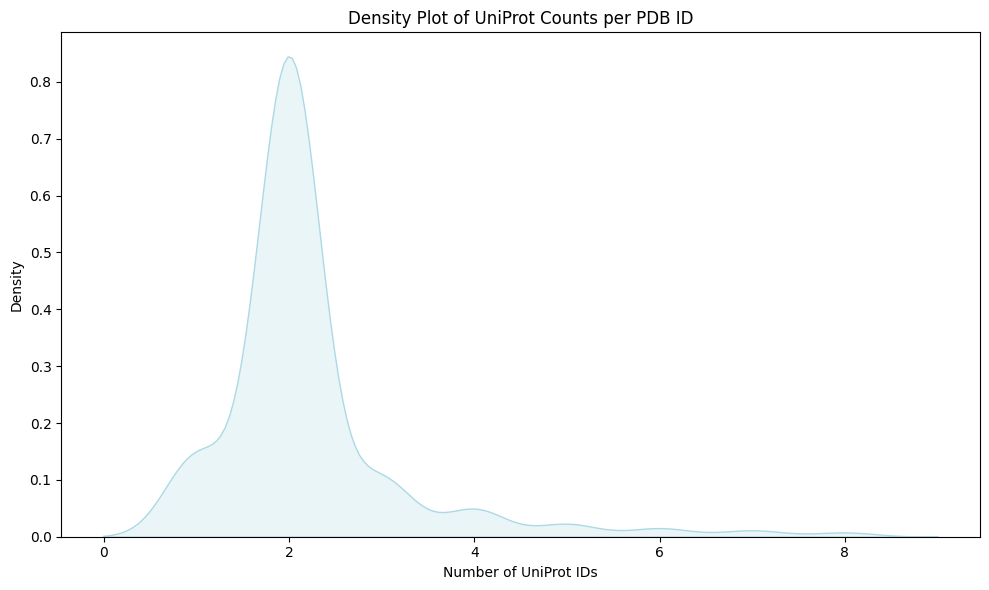

In [20]:
uniprot_counts_series = pd.Series(uniprot_counts_per_pdb)

plt.figure(figsize=(10, 6))
sns.kdeplot(uniprot_counts_series.values, fill=True, color='lightblue')
plt.title('Density Plot of UniProt Counts per PDB ID')
plt.xlabel('Number of UniProt IDs')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

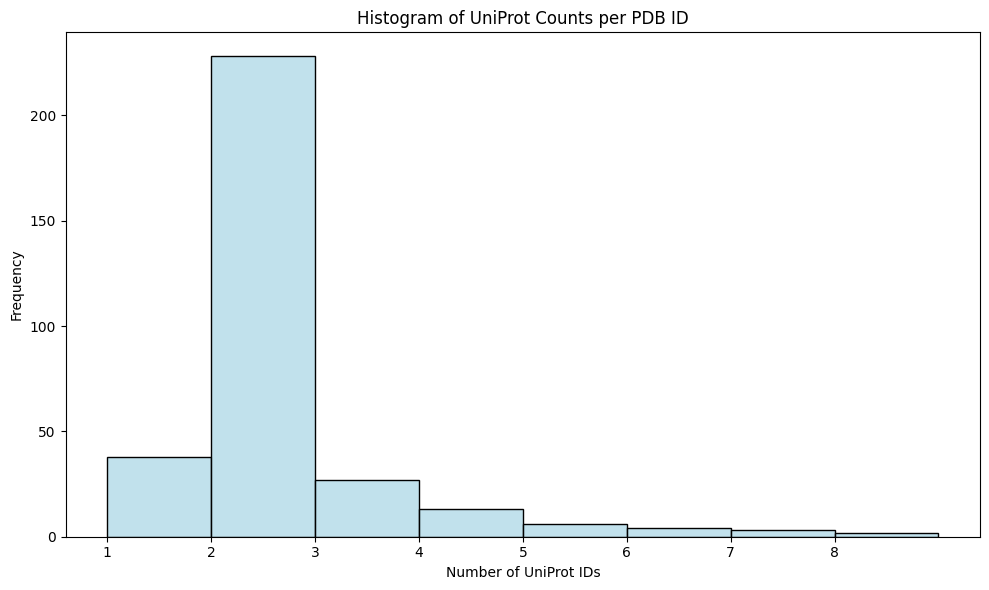

In [54]:
plt.figure(figsize=(10, 6))
sns.histplot(uniprot_counts_series.values, bins=range(1, max(uniprot_counts_series.values) + 2), kde=False, color='lightblue', edgecolor='black')
plt.title('Histogram of UniProt Counts per PDB ID')
plt.xlabel('Number of UniProt IDs')
plt.ylabel('Frequency')
plt.xticks(range(1, max(uniprot_counts_series.values) + 1))
plt.tight_layout()
plt.show()

From the plot we see that some PDB IDs have a single Uniprot ID associated:

In [21]:
min_uniprot_count = min(uniprot_counts_per_pdb.values())
print(f"The minimum number of UniProt IDs associated with a PDB ID is: {min_uniprot_count}")

The minimum number of UniProt IDs associated with a PDB ID is: 1


In [55]:
max_uniprot_count = max(uniprot_counts_per_pdb.values())
print(f"The maximum number of UniProt IDs associated with a PDB ID is: {max_uniprot_count}")

The maximum number of UniProt IDs associated with a PDB ID is: 8


In [56]:
prot_per_complex = {}

In [57]:
pdb_ids_with_one_uniprot = [pdb for pdb, count in uniprot_counts_per_pdb.items() if count == 1]
print(f"Number of PDB IDs with exactly one UniProt ID: {len(pdb_ids_with_one_uniprot)}")
print("PDB IDs with exactly one UniProt ID:")
for pdb_id in pdb_ids_with_one_uniprot:
    print(pdb_id)
prot_per_complex[1]=len(pdb_ids_with_one_uniprot)

Number of PDB IDs with exactly one UniProt ID: 38
PDB IDs with exactly one UniProt ID:
1BJ1
1CZ8
1JCK
1MHP
1N8Z
1NMB
1XGR
1XGT
1YQV
1YY9
2BDN
2JEL
2NYY
2NZ9
3EQS
3EQY
3G6D
3K2M
3L5X
3LNZ
3LZF
3N85
3NGB
3NPS
3SE8
3SE9
3W2D
4GXU
4HRN
4JPK
4KRL
4U6H
4ZS6
5C6T
5M2O
5UFE
5UFQ
5XCO


In [58]:
pdb_ids_with_2_uniprot = [pdb for pdb, count in uniprot_counts_per_pdb.items() if count == 2]
print(f"Number of PDB IDs with exactly two UniProt IDs: {len(pdb_ids_with_2_uniprot)}")
#print("First 10 PDB IDs with exactly one UniProt ID:")
#for pdb_id in pdb_ids_with_2_uniprot:
    #print(pdb_id)
prot_per_complex[2]=len(pdb_ids_with_2_uniprot)

Number of PDB IDs with exactly two UniProt IDs: 228


In [59]:
pdb_ids_with_3_uniprot = [pdb for pdb, count in uniprot_counts_per_pdb.items() if count == 3]
print(f"Number of PDB IDs with exactly 3 UniProt ID: {len(pdb_ids_with_3_uniprot)}")
print("PDB IDs with exactly 3 UniProt ID:")
for pdb_id in pdb_ids_with_3_uniprot:
    print(pdb_id)
prot_per_complex[3]=len(pdb_ids_with_3_uniprot)

Number of PDB IDs with exactly 3 UniProt ID: 27
PDB IDs with exactly 3 UniProt ID:
1CBW
1CSE
1DQJ
1JRH
1MLC
1VFB
2E7L
2OI9
3AAA
3BDY
3BE1
3BT1
3D3V
3H9S
3PWP
3QDG
3QDJ
3SE3
3SE4
3SZK
4B0M
4FTV
4K71
4L3E
4NKQ
4NM8
4PWX


In [60]:
pdb_ids_with_4_uniprot = [pdb for pdb, count in uniprot_counts_per_pdb.items() if count == 4]
print(f"Number of PDB IDs with exactly 4 UniProt ID: {len(pdb_ids_with_4_uniprot)}")
print("PDB IDs with exactly 4 UniProt ID:")
for pdb_id in pdb_ids_with_4_uniprot:
    print(pdb_id)
prot_per_complex[4]=len(pdb_ids_with_4_uniprot)

Number of PDB IDs with exactly 4 UniProt ID: 13
PDB IDs with exactly 4 UniProt ID:
1AHW
1DVF
2DSQ
2JCC
2UWE
3BN9
3QIB
3VR6
4JFD
4JFE
4JGH
4N8V
5E9D


In [61]:
pdb_ids_with_5_uniprot = [pdb for pdb, count in uniprot_counts_per_pdb.items() if count == 5]
print(f"Number of PDB IDs with exactly 5 UniProt ID: {len(pdb_ids_with_5_uniprot)}")
print("PDB IDs with exactly 5 UniProt ID:")
for pdb_id in pdb_ids_with_5_uniprot:
    print(pdb_id)
prot_per_complex[5]=len(pdb_ids_with_5_uniprot)

Number of PDB IDs with exactly 5 UniProt ID: 6
PDB IDs with exactly 5 UniProt ID:
1LP9
1MI5
2AK4
2J8U
2P5E
4JFF


In [62]:
pdb_ids_with_6_uniprot = [pdb for pdb, count in uniprot_counts_per_pdb.items() if count == 6]
print(f"Number of PDB IDs with exactly 6 UniProt ID: {len(pdb_ids_with_6_uniprot)}")
print("PDB IDs with exactly 6 UniProt ID:")
for pdb_id in pdb_ids_with_6_uniprot:
    print(pdb_id)
prot_per_complex[6]=len(pdb_ids_with_6_uniprot)

Number of PDB IDs with exactly 6 UniProt ID: 4
PDB IDs with exactly 6 UniProt ID:
1OGA
2VLJ
4MNQ
4OZG


In [63]:
pdb_ids_with_7_uniprot = [pdb for pdb, count in uniprot_counts_per_pdb.items() if count == 7]
print(f"Number of PDB IDs with exactly 7 UniProt ID: {len(pdb_ids_with_7_uniprot)}")
print("PDB IDs with exactly 7 UniProt ID:")
for pdb_id in pdb_ids_with_7_uniprot:
    print(pdb_id)
prot_per_complex[7]=len(pdb_ids_with_7_uniprot)

Number of PDB IDs with exactly 7 UniProt ID: 3
PDB IDs with exactly 7 UniProt ID:
2BNQ
2BNR
2VLR


In [64]:
pdb_ids_with_8_uniprot = [pdb for pdb, count in uniprot_counts_per_pdb.items() if count == 8]
print(f"Number of PDB IDs with exactly 8 UniProt ID: {len(pdb_ids_with_8_uniprot)}")
print("PDB IDs with exactly 8 UniProt ID:")
for pdb_id in pdb_ids_with_8_uniprot:
    print(pdb_id)
prot_per_complex[8]=len(pdb_ids_with_8_uniprot)

Number of PDB IDs with exactly 8 UniProt ID: 2
PDB IDs with exactly 8 UniProt ID:
1AO7
1BD2


In [65]:
print(prot_per_complex)

{1: 38, 2: 228, 3: 27, 4: 13, 5: 6, 6: 4, 7: 3, 8: 2}
